In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Cell 2 — Shape & nulls
print(df.shape)
print(df.isnull().sum())
print(df['Churn'].value_counts(normalize=True))

(7043, 21)
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


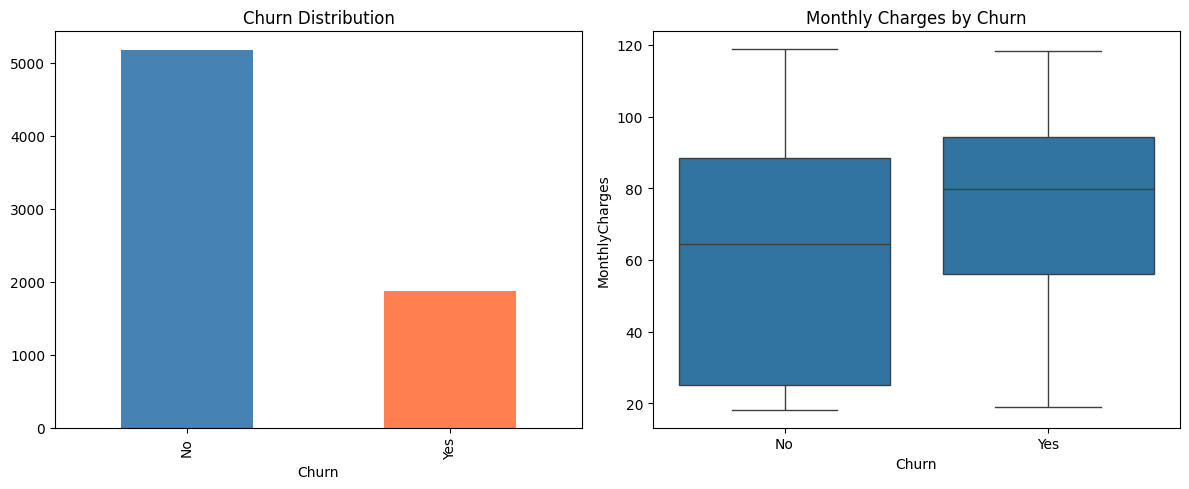

In [4]:
# Cell 3 — Churn rate visualization
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','coral'])
axes[0].set_title('Churn Distribution')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1])
axes[1].set_title('Monthly Charges by Churn')
plt.tight_layout()
plt.savefig('churn_eda.png', dpi=150)
plt.show()

Correlation heatmap

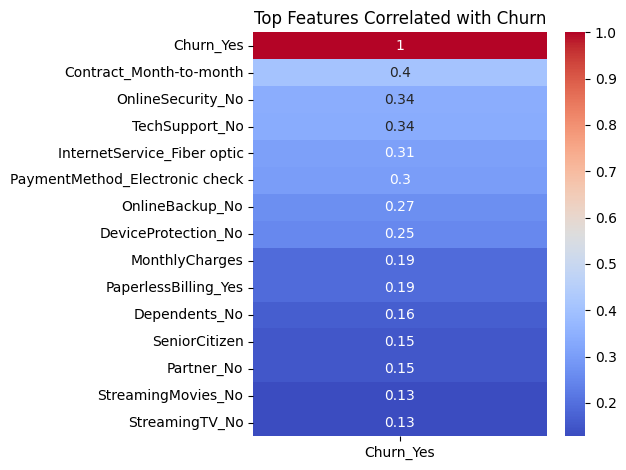

In [5]:
# Cell 4 — Correlation heatmap
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df_enc = pd.get_dummies(df.drop('customerID', axis=1))
corr = df_enc.corr()[['Churn_Yes']].sort_values('Churn_Yes', ascending=False).head(15)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Top Features Correlated with Churn')
plt.tight_layout()
plt.savefig('churn_corr.png', dpi=150)
plt.show()

Train model

In [6]:
# Cell 5 — Train model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X = df_enc.drop(['Churn_Yes','Churn_No'], axis=1)
y = df_enc['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.3f}")

              precision    recall  f1-score   support

       False       0.82      0.89      0.85      1033
        True       0.61      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.78      0.77      1407

ROC-AUC: 0.810


Revenue impact calculation (this is what BA's do differently from data scientists)

In [7]:
# Cell 6 — Revenue impact calculation (this is what BA's do differently from data scientists)
avg_monthly_revenue = df['MonthlyCharges'].mean()
churned_customers = (y_test == 1).sum()
correctly_flagged = ((y_pred == 1) & (y_test == 1)).sum()

monthly_revenue_saved = correctly_flagged * avg_monthly_revenue
annual_revenue_saved = monthly_revenue_saved * 12

print(f"Customers at-risk identified: {correctly_flagged}")
print(f"Est. Monthly Revenue Protected: ${monthly_revenue_saved:,.0f}")
print(f"Est. Annual Revenue Protected: ${annual_revenue_saved:,.0f}")

Customers at-risk identified: 174
Est. Monthly Revenue Protected: $11,275
Est. Annual Revenue Protected: $135,299


# New Section

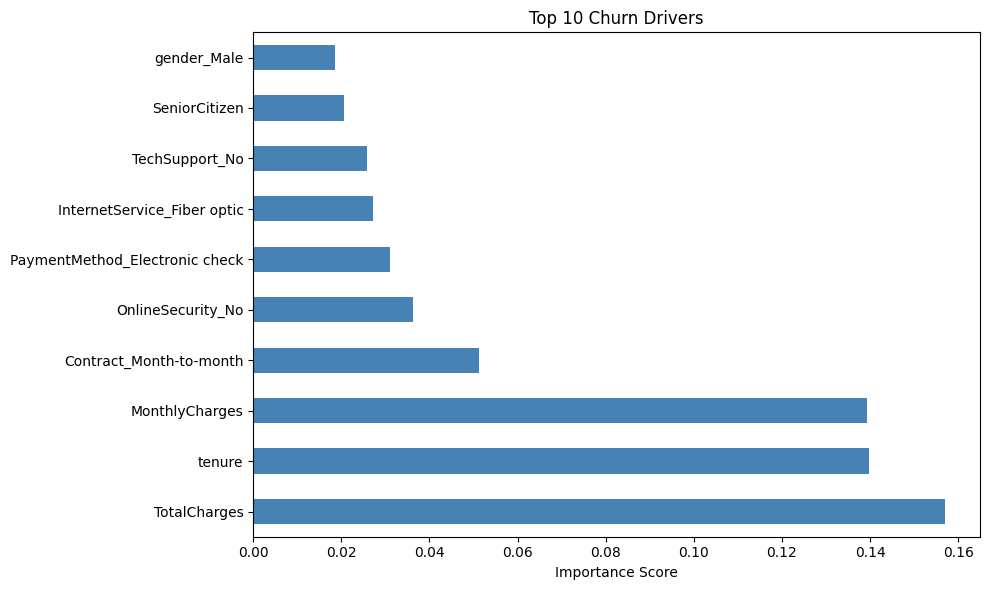

In [8]:
# Cell 7
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh', color='steelblue', figsize=(10,6))
plt.title('Top 10 Churn Drivers')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()